In [1]:
import pandas as pd

In [2]:
tt1 = pd.read_csv('mel_smps_all.csv')

In [3]:
tt2 = pd.read_csv('melpitz_station.csv')

In [4]:
tt1.columns

Index(['Unnamed: 0', 'Start_Date&Time', 'start_time', 'end_time', 'st_y',
       'ed_y', 'p_sys', 'T_sys', 'RHsh', 'nBn', '5.1', '5.7', '6.4', '7.1',
       '8', '8.9', '10', '11.2', '12.5', '14', '15.7', '17.5', '19.6', '22',
       '24.6', '27.5', '30.8', '34.4', '38.5', '43.1', '48.2', '53.9', '60.4',
       '67.5', '75.6', '84.6', '94.6', '105.9', '118.5', '132.5', '148.3',
       '165.9', '185.7', '207.7', '232.4', '260.1', '291', '325.6', '364.3',
       '407.7', '456.1', '510.4', '571.1', '639', '715', '800', 'SubAitken',
       'Aitken', 'Accumulation', 'Coarse'],
      dtype='object')

In [5]:
tt2.columns

Index(['Time', 'SO4', 'Org', 'NO3', 'NH4', 'eBC', 'Cl', 'Temp', 'RH', 'WS',
       'WD', 'SO2', 'O3', 'NO', 'NO2', 'Start_Date.Time', 'SubAitken',
       'Aitken', 'Accumulation', 'Coarse', 'Inorg'],
      dtype='object')

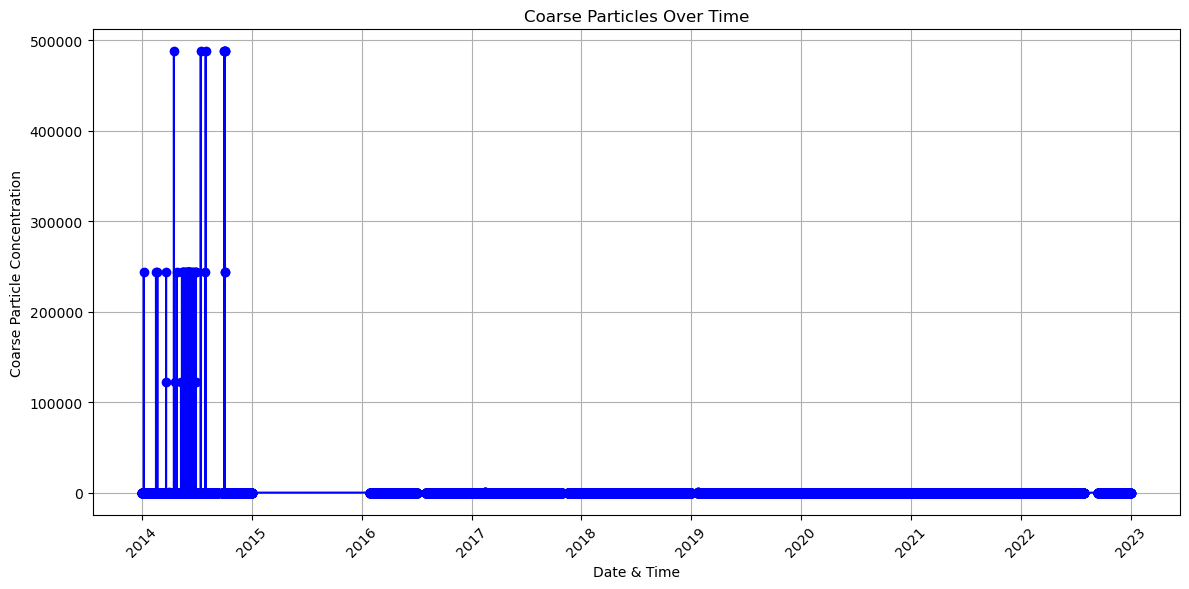

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming tt1 is your DataFrame
# Convert 'Start_Date&Time' to datetime if it's not already
tt1['Start_Date&Time'] = pd.to_datetime(tt1['Start_Date&Time'])

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(tt1['Start_Date&Time'], tt1['Coarse'], marker='o', linestyle='-', color='b')

# Formatting the plot
plt.title('Coarse Particles Over Time')
plt.xlabel('Date & Time')
plt.ylabel('Coarse Particle Concentration')
plt.grid(True)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent label cutoff

# Show the plot
plt.show()

C:\Users\chinthaparthy\AppData\Local\Temp\ipykernel_61236\2889500163.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tt2['Time'] = pd.to_datetime(tt2['Time'])


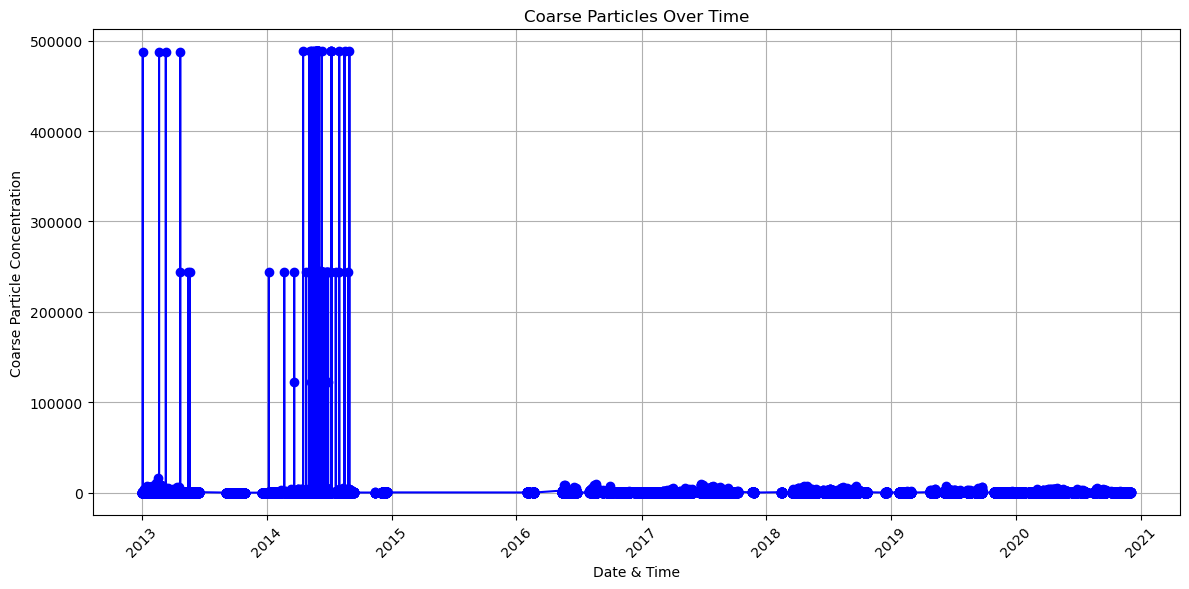

In [7]:
tt2['Time'] = pd.to_datetime(tt2['Time'])

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(tt2['Time'], tt2['Coarse'], marker='o', linestyle='-', color='b')

# Formatting the plot
plt.title('Coarse Particles Over Time')
plt.xlabel('Date & Time')
plt.ylabel('Coarse Particle Concentration')
plt.grid(True)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent label cutoff

# Show the plot
plt.show()

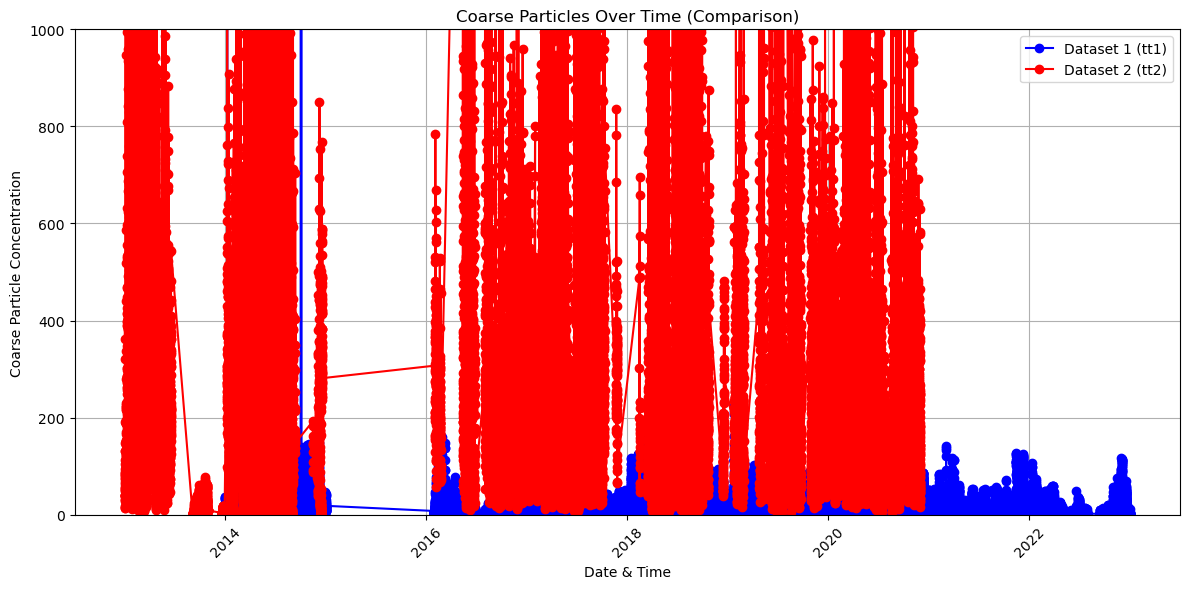

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert datetime columns
tt1['Start_Date&Time'] = pd.to_datetime(tt1['Start_Date&Time'])
tt2['Time'] = pd.to_datetime(tt2['Time'])

# Create a single figure
plt.figure(figsize=(12, 6))

# Plot both datasets with different colors/labels
plt.plot(tt1['Start_Date&Time'], tt1['Coarse'], marker='o', linestyle='-', color='b', label='Dataset 1 (tt1)')
plt.plot(tt2['Time'], tt2['Coarse'], marker='o', linestyle='-', color='r', label='Dataset 2 (tt2)')

# Set y-axis limit
plt.ylim(0, 1000)  # Fix y-axis from 0 to 1000

# Formatting
plt.title('Coarse Particles Over Time (Comparison)')
plt.xlabel('Date & Time')
plt.ylabel('Coarse Particle Concentration')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()  # Show legend to distinguish datasets
plt.tight_layout()

plt.show()

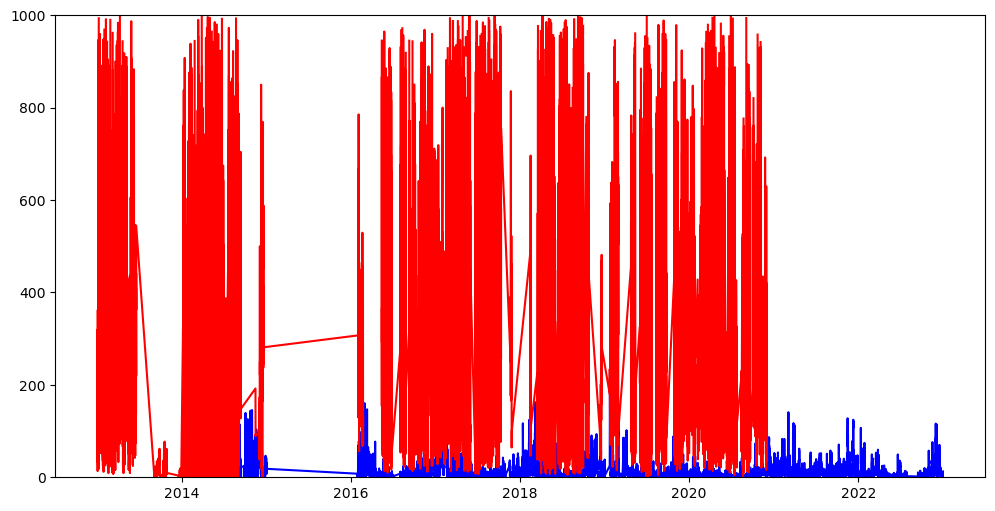

In [9]:
import numpy as np

# Mask values > 1000 as NaN (they won't be plotted)
tt1_masked = tt1.copy()
tt1_masked['Coarse'] = tt1_masked['Coarse'].where(tt1_masked['Coarse'] <= 1000, np.nan)

tt2_masked = tt2.copy()
tt2_masked['Coarse'] = tt2_masked['Coarse'].where(tt2_masked['Coarse'] <= 1000, np.nan)

# Plot masked data
plt.figure(figsize=(12, 6))
plt.plot(tt1_masked['Start_Date&Time'], tt1_masked['Coarse'], linestyle='-', color='blue', label='Dataset 1 (Masked >1000)')
plt.plot(tt2_masked['Time'], tt2_masked['Coarse'], linestyle='-', color='red', label='Dataset 2 (Masked >1000)')
plt.ylim(0, 1000)
# (Add the same formatting as above)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# Load your data
ttt = pd.read_csv("melpitz_station.csv")
ttt['timeStamp'] = pd.to_datetime(ttt['Time'])

# Create a single figure with subplots
n_cols = 3
n_rows = (len(ttt.columns) - 1 + n_cols - 1) // n_cols  # Calculate needed rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
fig.suptitle('Time Series of All Parameters', y=1.02, fontsize=14)
axes = axes.flatten()

# Plot each column (except timestamp)
for i, col in enumerate([c for c in ttt.columns if c != 'timeStamp']):
    ax = axes[i]
    
    # Plot data
    ax.plot(ttt['timeStamp'], ttt[col], linewidth=1)
    
    # Formatting
    ax.set_title(col, pad=10)
    ax.grid(True, alpha=0.3)
    
    # Configure clean year-only x-axis
    ax.xaxis.set_major_locator(mdates.YearLocator())  # One tick per year
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Just show year
    
    # Rotate year labels slightly for better spacing
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# Hide any empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=3.0, h_pad=2.0, w_pad=2.0)  # Extra padding
plt.savefig('all_parameters_subplots_clean_years1.png', bbox_inches='tight', dpi=300)
plt.show()

C:\Users\chinthaparthy\AppData\Local\Temp\ipykernel_33900\2241741461.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ttt['timeStamp'] = pd.to_datetime(ttt['Time'])


KeyboardInterrupt: 

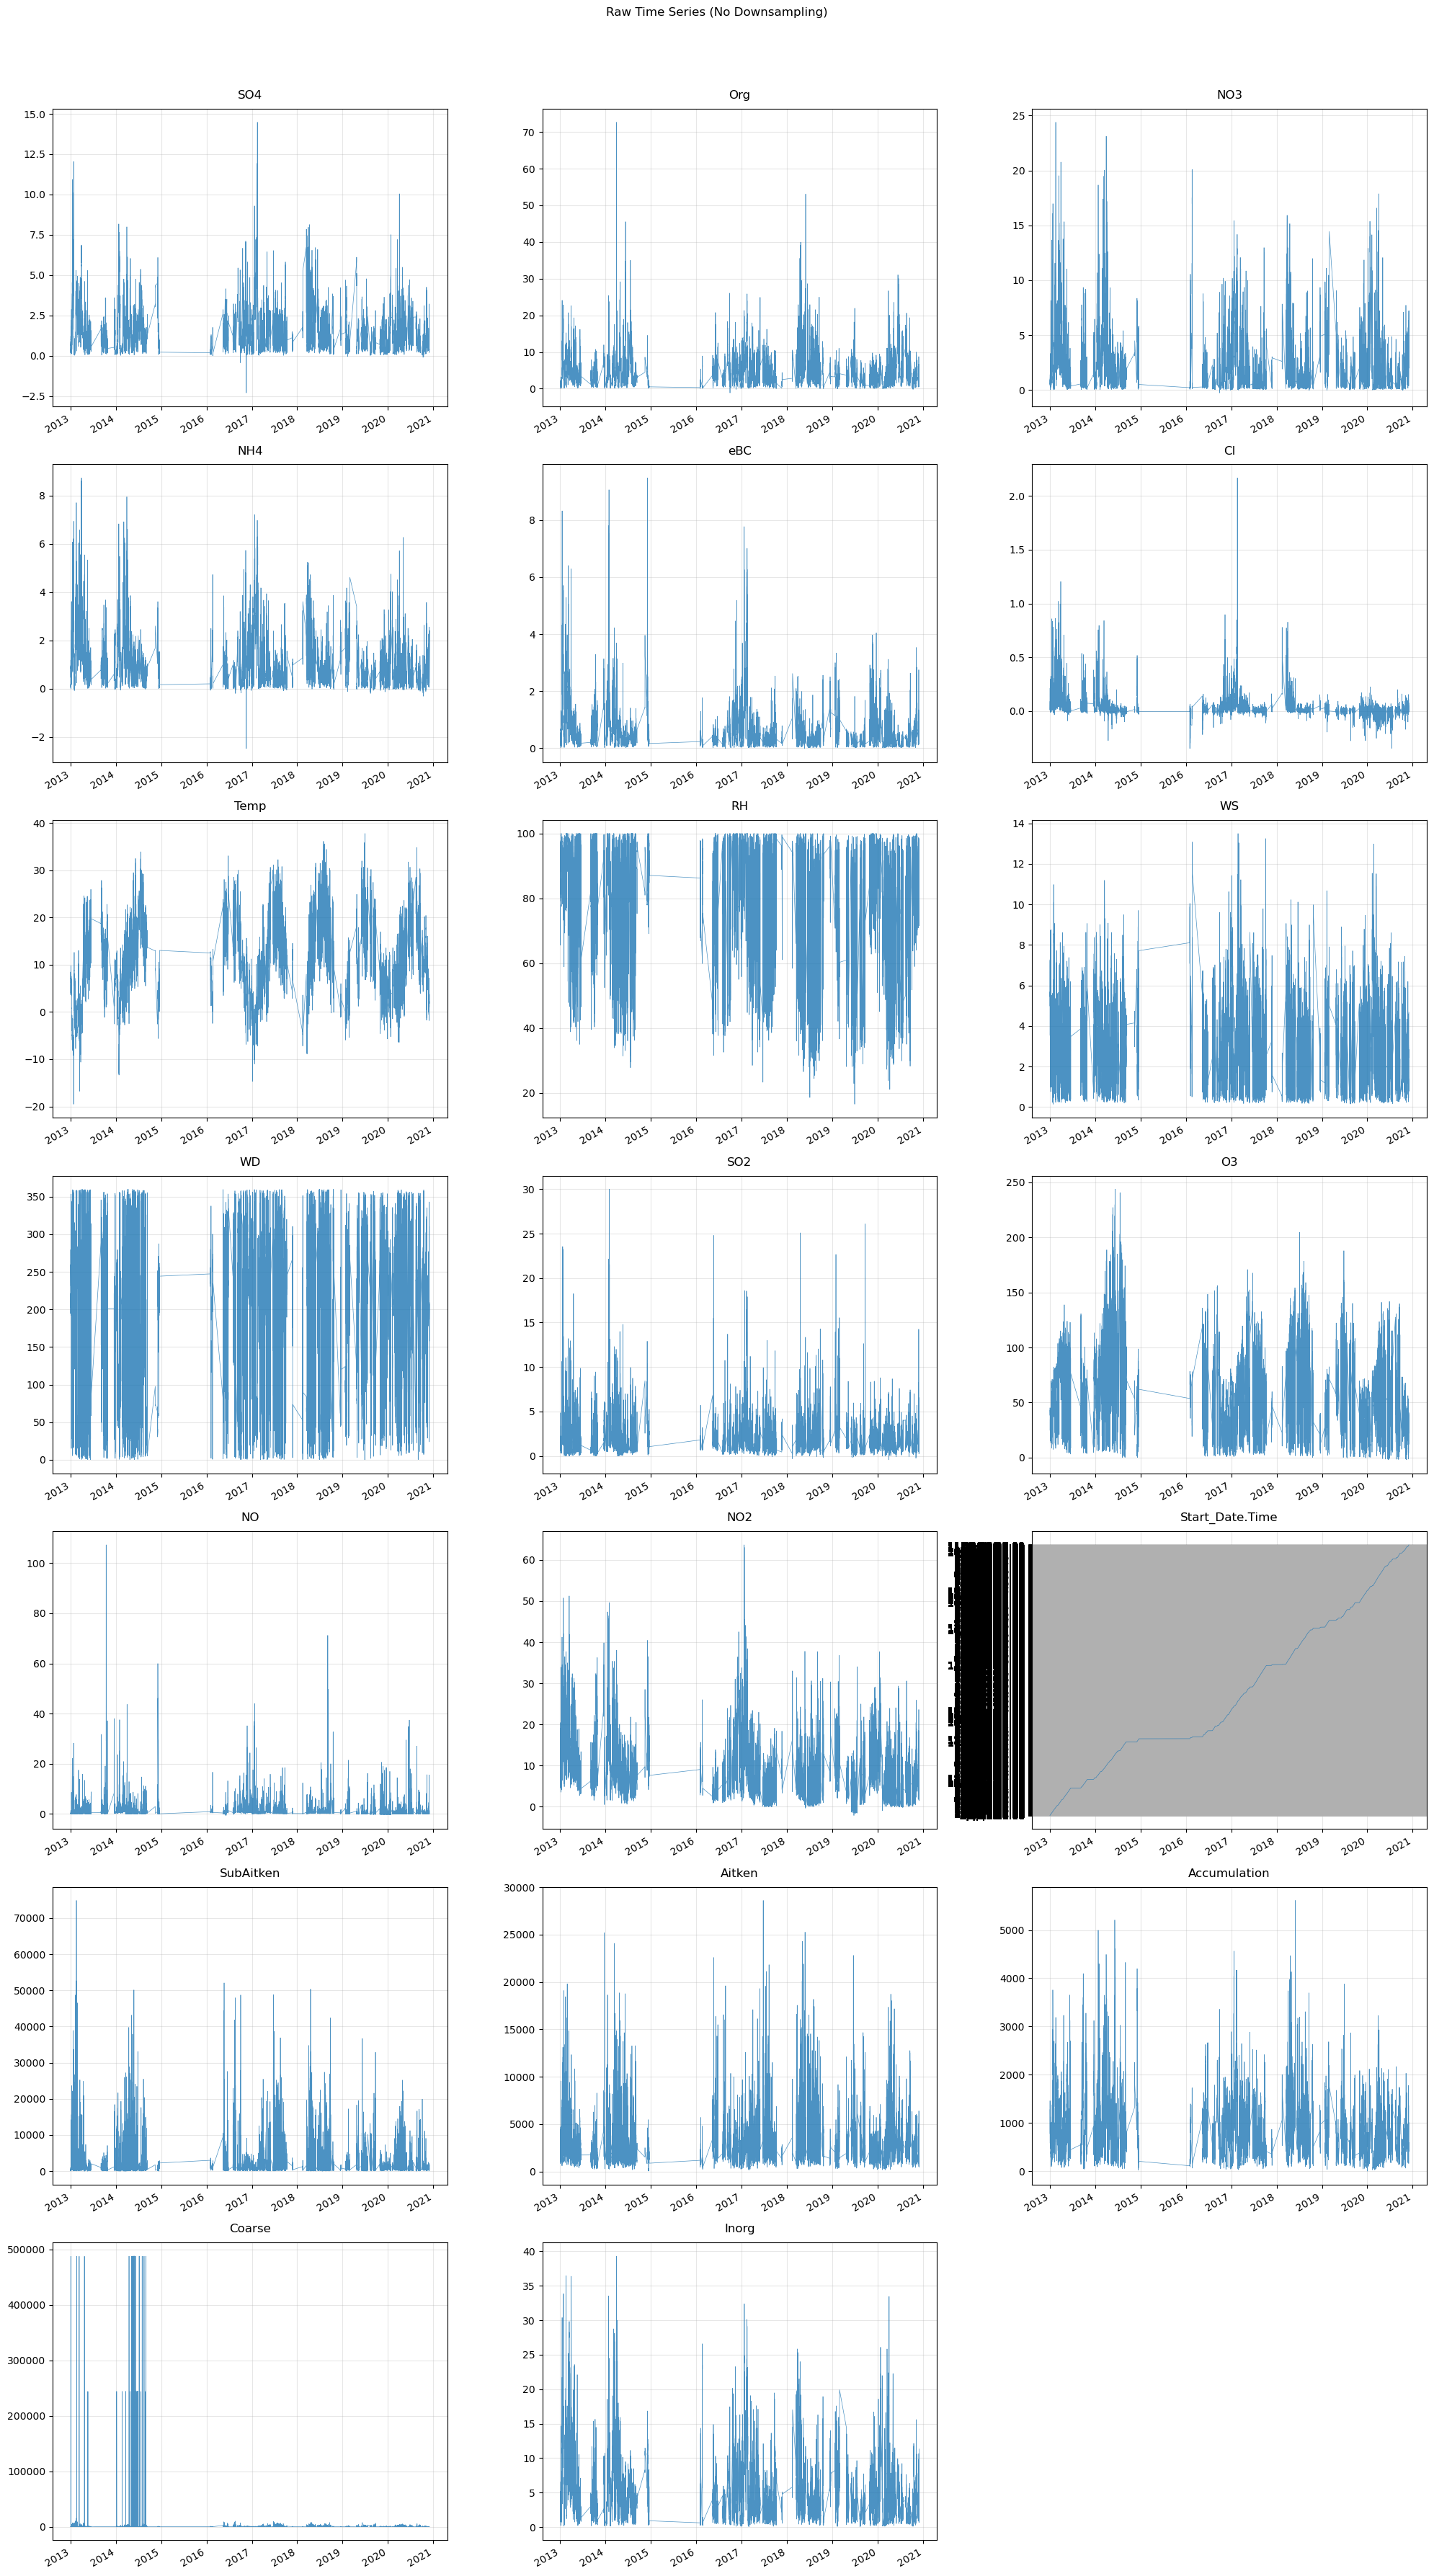

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load data with correct datetime parsing
ttt = pd.read_csv("melpitz_station.csv")
ttt['timeStamp'] = pd.to_datetime(ttt['Time'], format='%m/%d/%y %H:%M')  # Month/Day/Year Hour:Minute

# Create subplots
n_cols = 3
params = [c for c in ttt.columns if c not in ['Time', 'timeStamp']]
n_rows = (len(params) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows), tight_layout=True)
fig.suptitle('Raw Time Series (No Downsampling)', y=1.02)

# Plot RAW data with performance optimizations
for i, (ax, col) in enumerate(zip(axes.flatten(), params)):
    # Plot all raw points (no resampling)
    ax.plot(ttt['timeStamp'], ttt[col], 
            linewidth=0.5,  # Thinner line
            markersize=0,   # No markers
            alpha=0.8)      # Slight transparency
    
    ax.set_title(col, pad=10)
    ax.grid(True, alpha=0.3)
    
    # Optimized x-axis formatting
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# Hide empty subplots
for j in range(i+1, len(axes.flatten())):
    fig.delaxes(axes.flatten()[j])

plt.savefig('raw_timeseries.png', bbox_inches='tight', dpi=150)
plt.show()

In [2]:
import pandas as pd

diameters = [5.1, 5.7, 6.4, 7.1, 8, 8.9, 10, 11.2, 12.5, 14, 15.7, 17.5, 19.6, 22, 24.6, 27.5, 30.8, 34.4, 38.5, 43.1, 48.2, 53.9, 60.4, 67.5, 75.6, 84.6, 94.6, 105.9, 118.5, 132.5, 148.3, 165.9, 185.7, 207.7, 232.4, 260.1, 291, 325.6, 364.3, 407.7, 456.1, 510.4, 571.1, 639, 715, 800]
diameter_df = pd.DataFrame({'Diameter_nm': diameters})
diameter_df

,Diameter_nm
0,5.1
1,5.7
2,6.4
3,7.1
4,8.0
5,8.9
6,10.0
7,11.2
8,12.5
9,14.0


In [ ]:
final_tt = pd.DataFrame({
    'datetime': pd.to_datetime(tt['Start_Date&Time']),
    'SubAitken': tt.iloc[:, 10],  # 10th column (bin_01)
    'Aitken': tt.iloc[:, 11:31].sum(axis=1),  # columns 11 to 36 (bin_02 to bin_37)
    'Accumulation': tt.iloc[:, 31:51].sum(axis=1),  # columns 37 to 50 (bin_38 to bin_51)
    'Coarse': tt.iloc[:, 51:56].sum(axis=1)  # columns 51 to 55 (bin_52 to bin_56)
})

In [ ]:
df['SubAitken'] = df.iloc[:,9:22].sum(axis=1)
df['Aitken'] = df.iloc[:,22:36].sum(axis=1)
df['Accumulation'] =df.iloc[:,36:50].sum(axis=1)
df['Coarse'] =df.iloc[:,50:55].sum(axis=1)

In [5]:
tt2 = pd.read_csv('mel_smps_all.csv')

In [17]:
tt2.iloc[:,23:38].head()

,22,24.6,27.5,30.8,34.4,38.5,43.1,48.2,53.9,60.4,67.5,75.6,84.6,94.6,105.9
0,124.104416,183.698751,282.351172,364.948060,479.444574,557.545480,619.970747,663.703120,690.893736,689.505290,698.675967,632.276661,600.539574,609.614200,583.113123
1,140.935802,192.926526,266.541555,328.436073,414.226870,467.209367,491.501452,519.390314,524.999367,496.411937,495.655019,447.166235,419.607066,417.665711,393.926971
2,105.311066,180.606968,251.372585,306.562216,401.587219,452.279763,461.447815,486.813281,507.727021,482.160044,473.084815,447.066047,437.898281,435.513783,416.247738
3,118.393703,147.620456,216.617574,287.332698,341.368453,386.258649,422.851194,433.013150,442.654164,430.617219,432.566201,418.769097,421.106236,420.130703,413.298084
4,85.119952,115.245737,161.968145,195.396006,231.979221,266.046097,288.596899,294.818567,303.224902,299.707694,308.024843,297.403903,293.718051,301.940379,306.727008


In [21]:
import pandas as pd

# Load data
tt1 = pd.read_csv("mel_smps_all.csv")
tt5 = pd.read_csv("melpitz_station.csv")

# 1. Clean raw data FIRST by removing entire rows with any size bin >100,000
def clean_raw_data(df):
    """Remove rows where any raw size bin exceeds 100,000 #/cm³"""
    size_bin_cols = [col for col in df.columns 
                    if col not in ['timeStamp'] 
                    and pd.api.types.is_numeric_dtype(df[col])]
    
    # Keep only rows where ALL size bins are <=100000
    clean_mask = (df[size_bin_cols] <= 100000).all(axis=1)
    print(f"Removed {len(df) - sum(clean_mask)} rows with values >100,000")
    return df[clean_mask]

tt1_clean = clean_raw_data(tt1)

# 2. Process cleaned data WITHOUT additional clipping
def process_tt1(df):
    processed = pd.DataFrame()
    processed['timeStamp'] = pd.to_datetime(df['Start_Date&Time'])
    
    # New division (no clipping needed)
    processed['SubAitken_new'] = df.iloc[:, 10]  # Already cleaned
    processed['Aitken_new'] = df.iloc[:, 11:31].sum(axis=1)
    processed['Accumulation_new'] = df.iloc[:, 31:51].sum(axis=1)
    processed['Coarse_new'] = df.iloc[:, 51:56].sum(axis=1)
    
    # Old division (no clipping needed)
    processed['SubAitken_old'] = df.iloc[:, 10:23].sum(axis=1)
    processed['Aitken_old'] = df.iloc[:, 23:37].sum(axis=1)
    processed['Accumulation_old'] = df.iloc[:, 37:51].sum(axis=1)
    processed['Coarse_old'] = df.iloc[:, 51:56].sum(axis=1)
    
    return processed

tt1_processed = process_tt1(tt1_clean)

# 3. Clean tt5 by removing existing aerosol columns
aerosol_cols = ['SubAitken', 'Aitken', 'Accumulation', 'Coarse',
               'SubAitken_new', 'Aitken_new', 'Accumulation_new', 'Coarse_new',
               'SubAitken_old', 'Aitken_old', 'Accumulation_old', 'Coarse_old']

tt5_clean = tt5.drop(columns=aerosol_cols, errors='ignore')


tt5_clean['timeStamp'] = pd.to_datetime(tt5_clean['Time'], errors='coerce')
tt1_processed['timeStamp'] = pd.to_datetime(tt1_processed['timeStamp'], errors='coerce')
# 4. Merge with tolerance
final_data = pd.merge_asof(
    tt5_clean.sort_values('timeStamp'),
    tt1_processed.sort_values('timeStamp'),
    on='timeStamp',
    direction='nearest',
    tolerance=pd.Timedelta('5min')
)

final_data = final_data.dropna()

# Save results
final_data.to_csv("cleaned_merged_data1.csv", index=False)
print(f"Final dataset contains {len(final_data)} clean rows")

Removed 59 rows with values >100,000


C:\Users\chinthaparthy\AppData\Local\Temp\ipykernel_79056\3281985661.py:50: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tt5_clean['timeStamp'] = pd.to_datetime(tt5_clean['Time'], errors='coerce')


Final dataset contains 28535 clean rows


In [22]:
import pandas as pd

# Load data
tt1 = pd.read_csv("mel_smps_all.csv")
tt5 = pd.read_csv("melpitz_station.csv")

# 1. Clean raw data by removing rows with any size bin >100,000
def clean_raw_data(df):
    size_bin_cols = [col for col in df.columns 
                    if col not in ['timeStamp'] 
                    and pd.api.types.is_numeric_dtype(df[col])]
    clean_mask = (df[size_bin_cols] <= 100000).all(axis=1)
    print(f"Removed {len(df) - sum(clean_mask)} rows with values >100,000")
    return df[clean_mask]

tt1_clean = clean_raw_data(tt1)

# 2. Process cleaned data
def process_tt1(df):
    processed = pd.DataFrame()
    processed['timeStamp'] = pd.to_datetime(df['Start_Date&Time'])
    
    processed['SubAitken_new'] = df.iloc[:, 10]
    processed['Aitken_new'] = df.iloc[:, 11:31].sum(axis=1)
    processed['Accumulation_new'] = df.iloc[:, 31:51].sum(axis=1)
    processed['Coarse_new'] = df.iloc[:, 51:56].sum(axis=1)
    
    processed['SubAitken_old'] = df.iloc[:, 10:23].sum(axis=1)
    processed['Aitken_old'] = df.iloc[:, 23:37].sum(axis=1)
    processed['Accumulation_old'] = df.iloc[:, 37:51].sum(axis=1)
    processed['Coarse_old'] = df.iloc[:, 51:56].sum(axis=1)
    
    return processed

tt1_processed = process_tt1(tt1_clean)

# 3. Clean tt5 by removing aerosol columns
aerosol_cols = ['SubAitken', 'Aitken', 'Accumulation', 'Coarse',
               'SubAitken_new', 'Aitken_new', 'Accumulation_new', 'Coarse_new',
               'SubAitken_old', 'Aitken_old', 'Accumulation_old', 'Coarse_old']

tt5_clean = tt5.drop(columns=aerosol_cols, errors='ignore')
tt5_clean['timeStamp'] = pd.to_datetime(tt5_clean['Time'], errors='coerce')

# 4. Merge with tolerance
final_data = pd.merge_asof(
    tt5_clean.sort_values('timeStamp'),
    tt1_processed.sort_values('timeStamp'),
    on='timeStamp',
    direction='nearest',
    tolerance=pd.Timedelta('5min')
).dropna()

# 5. Remove duplicate rows (NEW STEP)
final_data = final_data.drop_duplicates(
    subset=['timeStamp'],  # Or list all columns you want to check
    keep='first'
)
print(f"Removed {len(final_data) - len(final_data.drop_duplicates())} duplicates")

# Save results
final_data.to_csv("cleaned_merged_data2.csv", index=False)
print(f"Final dataset contains {len(final_data)} unique rows")

Removed 59 rows with values >100,000


C:\Users\chinthaparthy\AppData\Local\Temp\ipykernel_79056\4084082414.py:43: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tt5_clean['timeStamp'] = pd.to_datetime(tt5_clean['Time'], errors='coerce')


Removed 0 duplicates
Final dataset contains 25177 unique rows


In [23]:
tt5_updated = pd.read_csv("cleaned_merged_data2.csv")

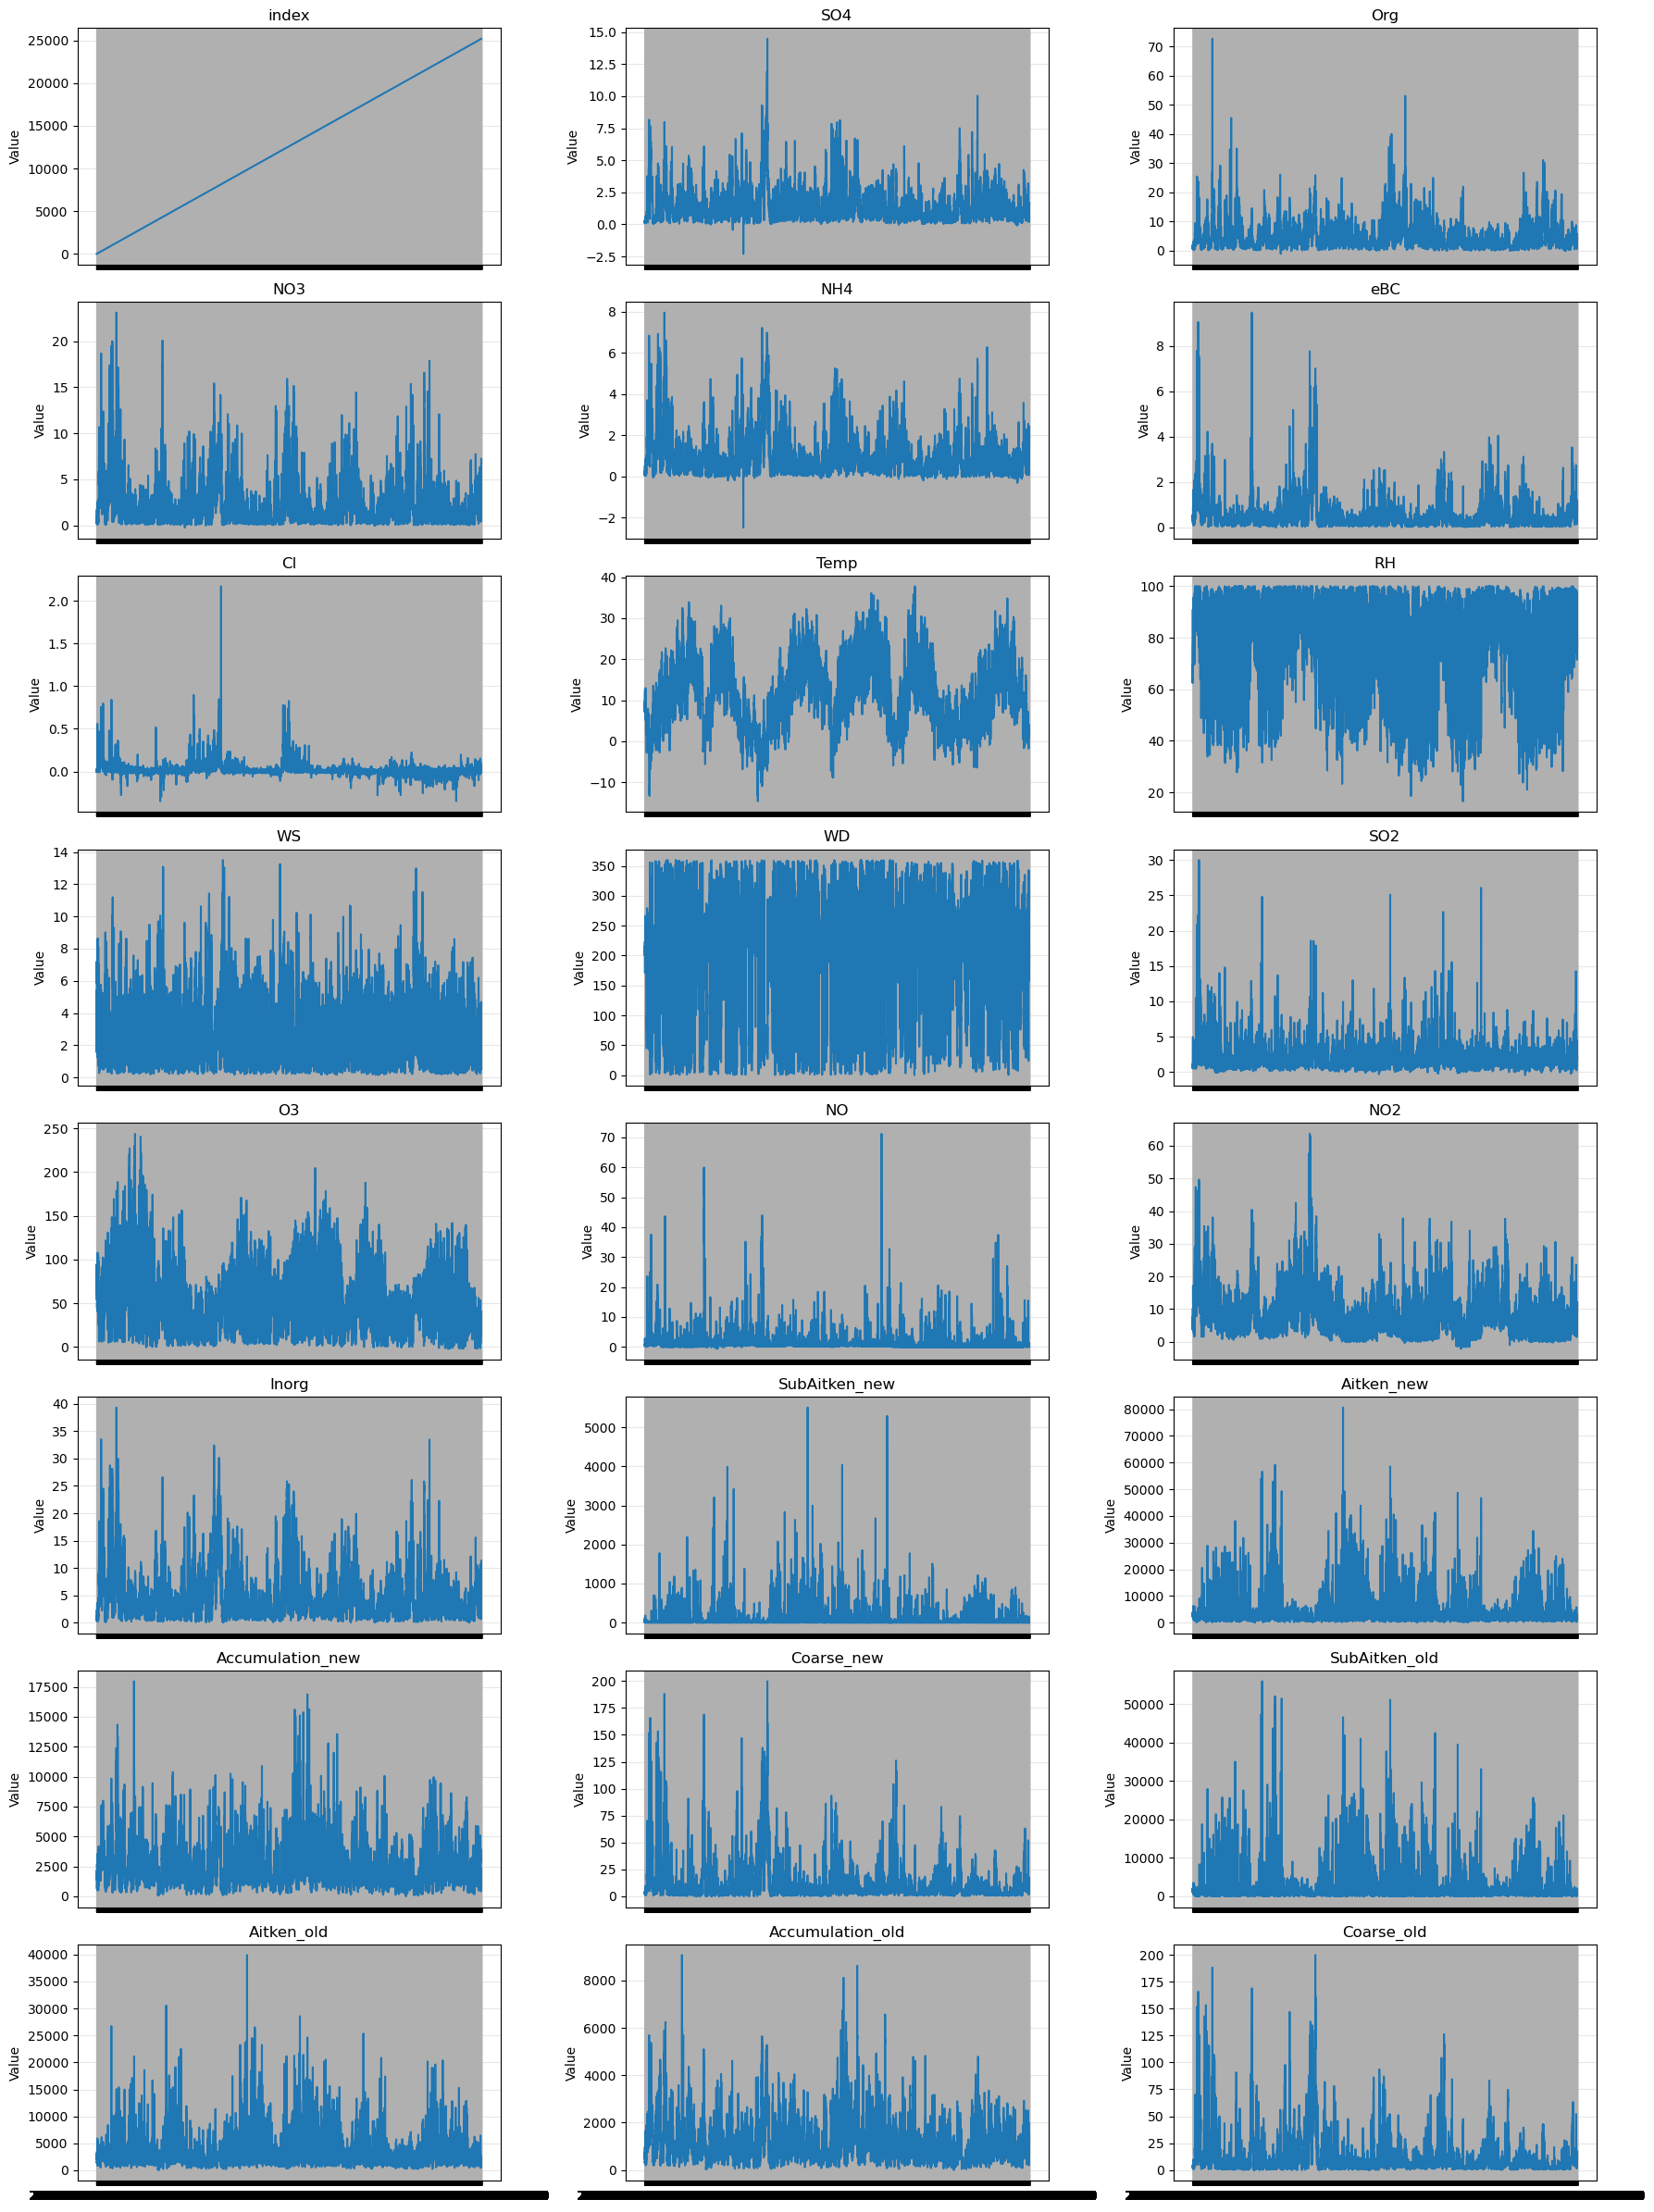

In [24]:
==================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================================import matplotlib.pyplot as plt
import numpy as np

# Reset index to make 'timeStamp' a column again
TTT2 = tt5_updated.reset_index()

# Now proceed with your plotting code
numeric_cols = TTT2.select_dtypes(include='number').columns
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 3 * n_rows), sharex=True)
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].plot(TTT2['timeStamp'], TTT2[col])
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')
    axes[i].grid(True, alpha=0.3)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [2]:
import pandas as pd

In [3]:
tt1 = pd.read_csv("Zepp_station.csv")

In [4]:
tt2 = pd.read_csv("merged_smps.csv")

In [5]:
tt1.columns

Index(['datetime', 'BC', 'Org', 'Inorg', 'CO2', 'CO', 'CH4', 'RH', 'T', 'WD',
       'WS', 'SubAitken', 'Aitken', 'Accumulation', 'Coarse'],
      dtype='object')

In [6]:
tt2.columns

Index(['time', 'SubAitken', 'Aitken', 'Accumulation', 'Coarse'], dtype='object')

In [7]:
import pandas as pd

# Read files
tt1 = pd.read_csv("Zepp_station.csv")
tt2 = pd.read_csv("merged_smps.csv")

# Rename datetime/time to a common column
tt1 = tt1.rename(columns={'datetime': 'timeStamp'})
tt2 = tt2.rename(columns={'time': 'timeStamp'})

# Ensure datetime format
tt1['timeStamp'] = pd.to_datetime(tt1['timeStamp'])
tt2['timeStamp'] = pd.to_datetime(tt2['timeStamp'])

# Columns to differentiate
cols_to_suffix = ['SubAitken', 'Aitken', 'Accumulation', 'Coarse']

# Add suffix to tt1 (old) and tt2 (new)
tt1 = tt1.rename(columns={col: f"{col}_old" for col in cols_to_suffix})
tt2 = tt2.rename(columns={col: f"{col}_new" for col in cols_to_suffix})

# Merge asof
final_data = pd.merge_asof(
    tt1.sort_values('timeStamp'),
    tt2.sort_values('timeStamp'),
    on='timeStamp',
    direction='nearest',
    tolerance=pd.Timedelta('5min')
).dropna()


C:\Users\chinthaparthy\AppData\Local\Temp\ipykernel_66356\1715002742.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tt1['timeStamp'] = pd.to_datetime(tt1['timeStamp'])


In [ ]:
final_data

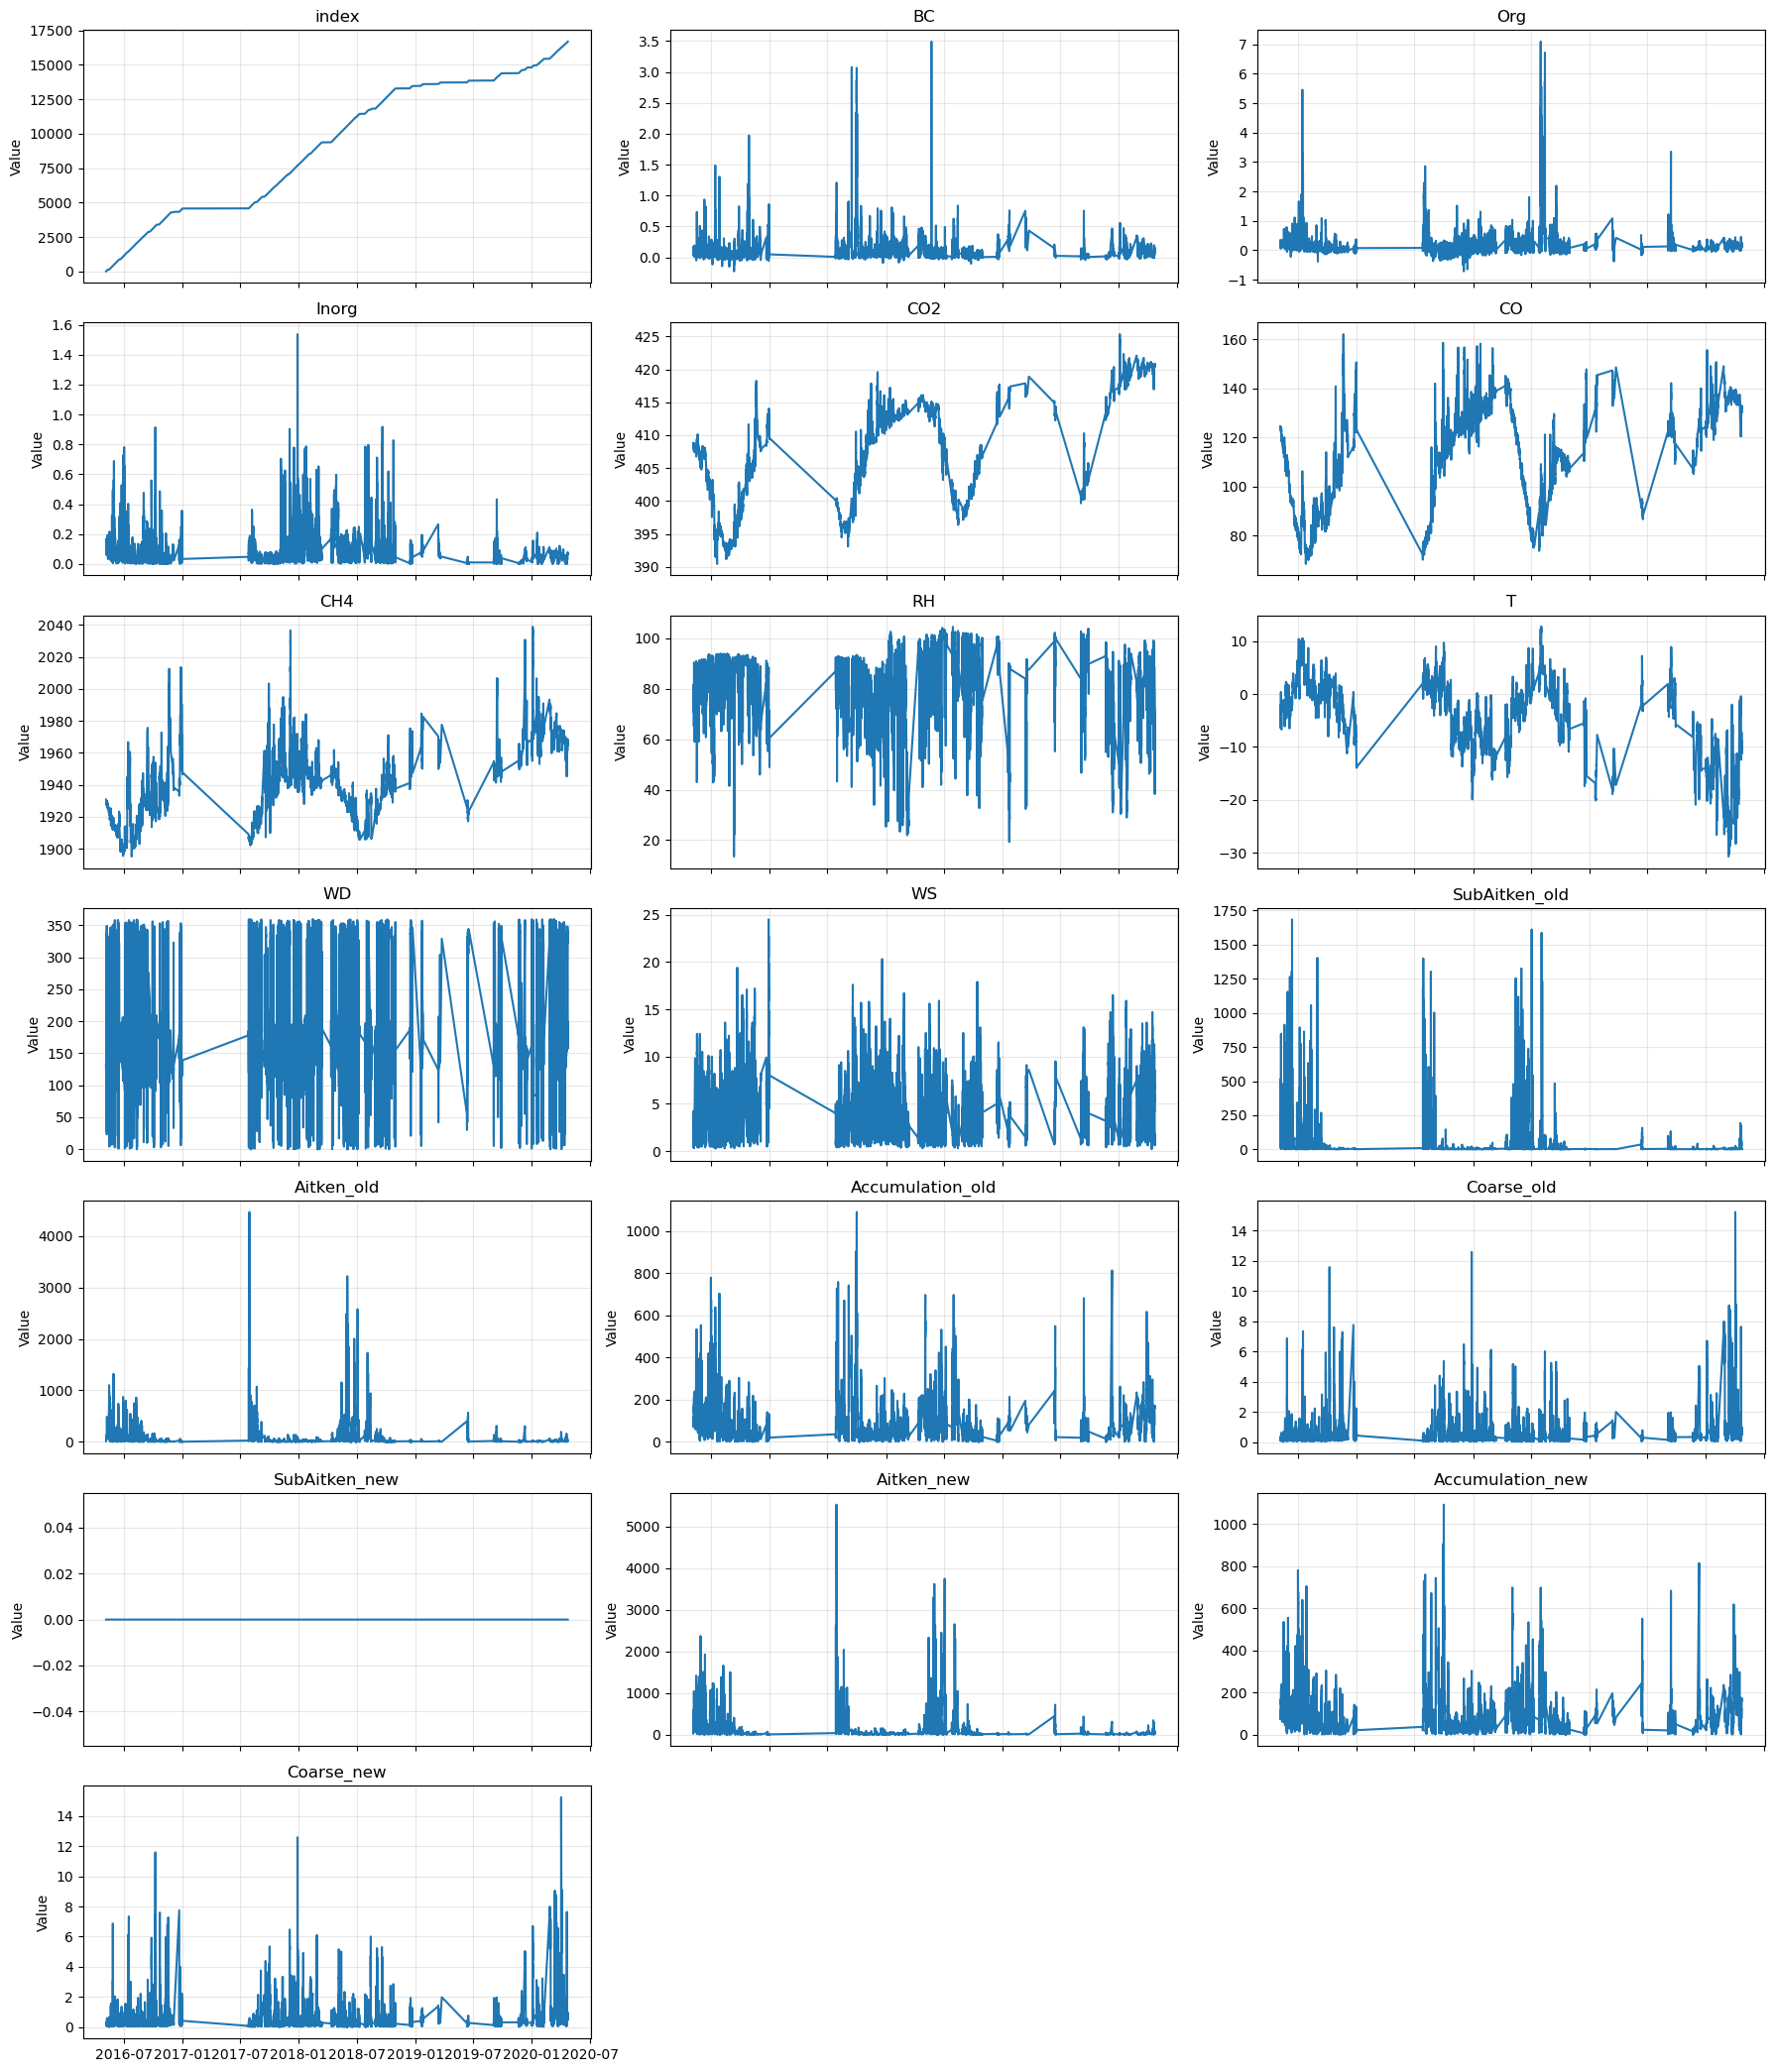

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Reset index to make 'timeStamp' a column again
TTT2 = final_data.reset_index()

# Now proceed with your plotting code
numeric_cols = TTT2.select_dtypes(include='number').columns
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 3 * n_rows), sharex=True)
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].plot(TTT2['timeStamp'], TTT2[col])
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')
    axes[i].grid(True, alpha=0.3)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [11]:
final_data = final_data.drop(columns=['SubAitken_new'])


In [12]:
final_data.to_csv("zepplin_data.csv", index=False)